Dispersion length 5.0000000000000006e+23


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

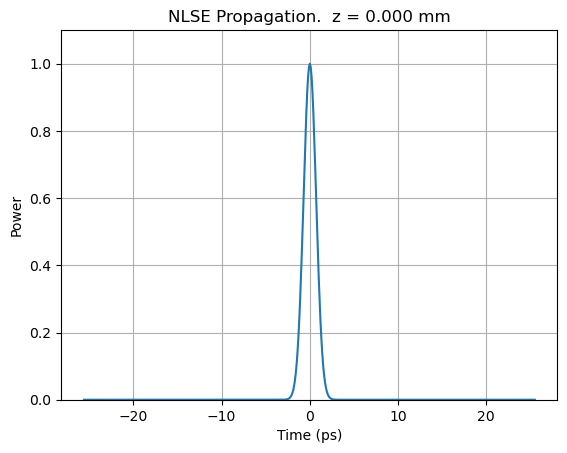

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import matplotlib.animation as animation

def nonlinear_schrodinger(N, T, dt, dz, gamma, beta2, Ld, initial_condition, video_name):
    """
    Simulates the nonlinear Schrodinger equation (NLSE) for waveguide propagation
    using the split-step Fourier method.

    Args:
        N (int): Number of spatial points.
        T (float): Total propagation distance.
        dt (float): Temporal resolution.
        dz (float): Propagation step size.
        gamma (float): Nonlinear coefficient.
        beta2 (float): Group velocity dispersion (GVD) coefficient.
        Ld (float): Dispersion length.
        initial_condition (numpy.ndarray): Initial condition for the field (e.g., a Gaussian pulse).
        video_name (str): Name of the output video file.

    Returns:
        numpy.ndarray: The field at each propagation step.
    """

    z = np.arange(0, T, dz)
    Nt = len(initial_condition)  #Number of temporal points
    field = np.zeros((len(z), Nt), dtype=complex)
    field[0, :] = initial_condition

    # Create frequency grid
    w = 2*np.pi*fftfreq(Nt, d=dt)

    # Linear operator in frequency domain
    linear_operator = np.exp(1j * (beta2/2) * w**2 * dz)

    # Split-step Fourier method
    for i in range(len(z) - 1):
        # Nonlinear step
        field[i, :] = field[i, :] * np.exp(1j * gamma * dz * np.abs(field[i, :])**2)

        # Linear step (dispersion)
        field[i, :] = ifft(linear_operator * fft(field[i, :]))

        # Store the field at each step

    return z, field

def gaussian_pulse(t, A, T0):
    """
    Generates a Gaussian pulse.

    Args:
        t (numpy.ndarray): Time vector.
        A (float): Amplitude.
        T0 (float): Pulse width.

    Returns:
        numpy.ndarray: The Gaussian pulse.
    """
    return A * np.exp(-(t**2) / (2 * T0**2))


if __name__ == "__main__":
    # Output video file name
    video_name = "nls_propagation.mp4"

    # Simulation parameters
    N = 256 # spatial points
    T = 10*1e-3  # Propagation distance (e.g., 10 mm)
    dt = 0.1 * 1e-12   # Time step (ps)
    dz = 1e-6     # Propagation step size (mm)
    gamma = 1.3 * 1e-3  # Nonlinear coefficient (1/(W*m))
    beta2 = -20 * 1e-27  # GVD parameter (ps^2/m)
    Ld = (dt*1e12)**2/abs(beta2) #Dispersion Length
    print(f"Dispersion length {Ld}")

    # Time vector
    Nt = 2*N # Increase temporal points
    t = np.arange(-Nt/2 * dt, Nt/2 * dt, dt)

    # Initial condition (Gaussian pulse)
    A = 1 #Pulse power
    T0 = 1 * 1e-12  # Pulse width (ps)
    initial_condition = gaussian_pulse(t, A, T0)

    # Run the simulation
    z, field = nonlinear_schrodinger(N, T, dt, dz, gamma, beta2, Ld, initial_condition,video_name)

    # Create the animation
    fig, ax = plt.subplots()
    line, = ax.plot(t*1e12, np.abs(field[0,:])**2)  # Plot initial condition in ps and power

    ax.set_xlabel('Time (ps)')
    ax.set_ylabel('Power')
    ax.set_title('NLSE Propagation')
    ax.set_ylim(0, np.max(np.abs(field)**2)*1.1)
    ax.grid(True)


    def update(frame, z):
        line.set_ydata(np.abs(field[frame,:])**2)
        ax.set_title(f"NLSE Propagation.  z = {z[frame]*1000:.3f} mm")  # Display distance in mm
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(z), fargs=(z,), blit=False, repeat=False)

    # Save the animation as a video
    writervideo = animation.FFMpegWriter(fps=30)  #Adjust fps as needed
    ani.save(video_name, writer=writervideo)

    print(f"Video saved as {video_name}")

    plt.show() # Show the animation (optional, comment out if only saving video)
